# **Visualize**

## Install Package

In [ ]:
pip install pyspark==3.5.0

## Prepare Data

### Connect to MinIO S3

In [ ]:
from pyspark.sql import SparkSession
from delta import *

class spark_connection:
    # Create a SparkSession
    builder = SparkSession.builder.appName("Data Lakehouse") \
        .master('local[*]') \
        .config("spark.hadoop.fs.s3a.aws.credentials.provider", "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider") \
        .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
        .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")

    spark = configure_spark_with_delta_pip(builder).getOrCreate()
    # spark = builder.getOrCreate()
    # Get the SparkContext from the SparkSession
    sc = spark.sparkContext
    # Set the MinIO access key, secret key, endpoint, and other configurations
    sc._jsc.hadoopConfiguration().set("fs.s3a.access.key", "khanhlq10")
    sc._jsc.hadoopConfiguration().set("fs.s3a.secret.key", "khanhlq10")
    sc._jsc.hadoopConfiguration().set("fs.s3a.endpoint", "http://localhost:9000")
    sc._jsc.hadoopConfiguration().set("fs.s3a.path.style.access", "true")
    sc._jsc.hadoopConfiguration().set("fs.s3a.connection.ssl.enabled", "false")
    sc._jsc.hadoopConfiguration().set("fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    sc._jsc.hadoopConfiguration().set("fs.s3a.connection.ssl.enabled", "false")

bucket = 'stock'

spark = spark_connection.spark

In [ ]:
spark.stop()

### Read and handle data

In [5]:
from pyspark.sql import functions as fn
from pyspark.sql.types import IntegerType,DateType
import pandas as pd

df = spark.read.option('header',True).load(f"s3a://{bucket}/gold/stock_price").sort(fn.desc('ngay'),fn.desc('version'))

df = df.selectExpr('ma as symbols','ngay as date','gia_dong_cua as close ', \
          'gia_mo_cua as open','gia_cao_nhat as max_price','gia_thap_nhat as min_price').toPandas()

df['date'] = pd.to_datetime(df['date'], format="%Y-%m-%d")
df = df.astype({'close': float, 'open': float, 'max_price': float, 'min_price': float})
# df.show()
# print(df.dtypes)
df.tail(5)
# df.info()


,symbols,date,close,open,max_price,min_price,year
5603,POW,2020-01-02,11900.0,11500.0,11900.0,11450.0,2020
5604,VHM,2020-01-02,84900.0,84500.0,85500.0,84500.0,2020
5605,FPT,2020-01-02,58600.0,58300.0,59000.0,58000.0,2020
5606,TCB,2020-01-02,23800.0,23550.0,23850.0,23500.0,2020
5607,HPG,2020-01-02,24000.0,23500.0,24000.0,23350.0,2020


### Line Chart

1. Tạo biểu đồ đường trung bình động và giá cổ phiếu FPT
2. Giá mở cửa và đóng cửa
3. Dự đoán giá cổ phiếu FPT bằng LSTM

**Tạo biểu đồ đường trung bình động và giá cổ phiếu FPT**

/var/folders/v9/hwgq0qks7k9gnnrrycgv2z5m0000gn/T/ipykernel_1686/97186046.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fpt['50_MA'] = df_fpt['close'].rolling(window=50).mean()


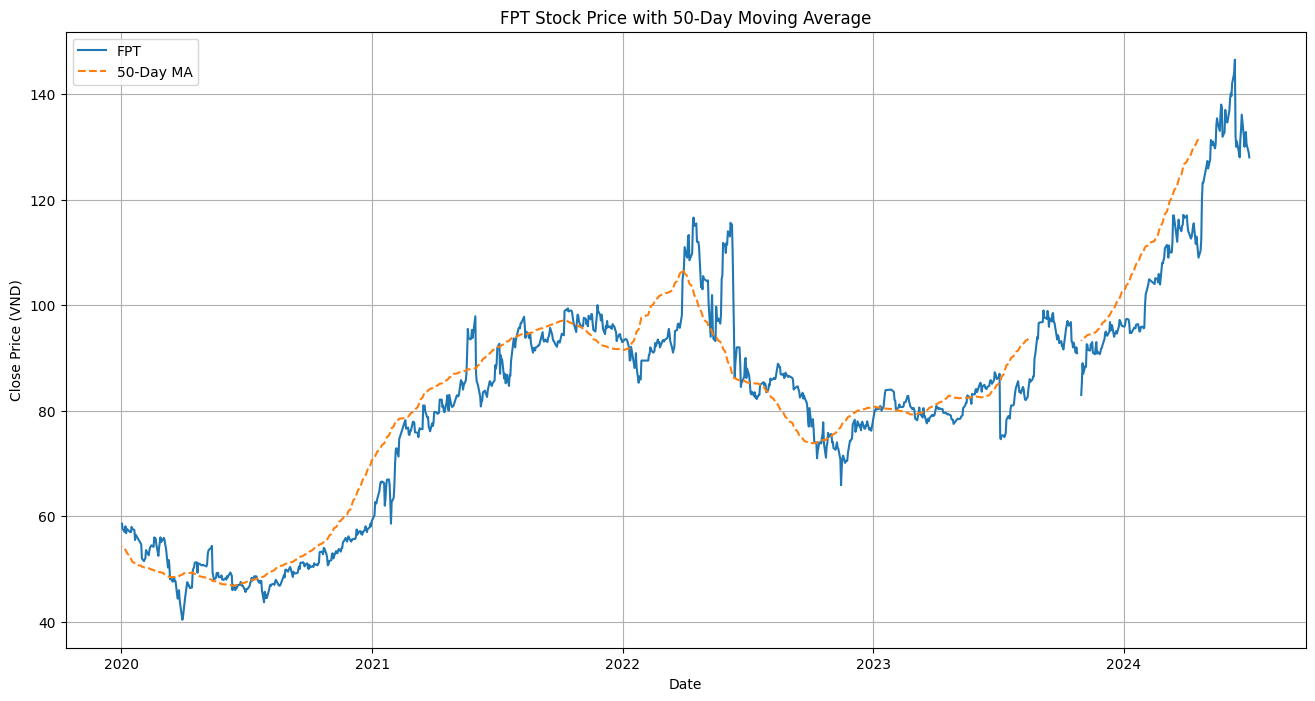

In [16]:
# Tạo biểu đồ đường hiển thị giá (toàn bộ dữ liệu)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_fpt = df[df['symbols'] == 'FPT']
# df_fpt.set_index('date',inplace=True)
date = df_fpt['date']
close = df_fpt['close'] / 1000

df_fpt['50_MA'] = df_fpt['close'].rolling(window=50).mean()
moving_average_50d= df_fpt['50_MA'] / 1000

plt.figure(figsize=(16,8))

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))

plt.plot(date,close, label='FPT')
plt.plot(date,moving_average_50d, label='50-Day MA', linestyle='--')

plt.title('FPT Stock Price with 50-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Close Price (VND)')

plt.legend()
plt.grid(True)

plt.show()

**Giá mở cửa và đóng cửa**

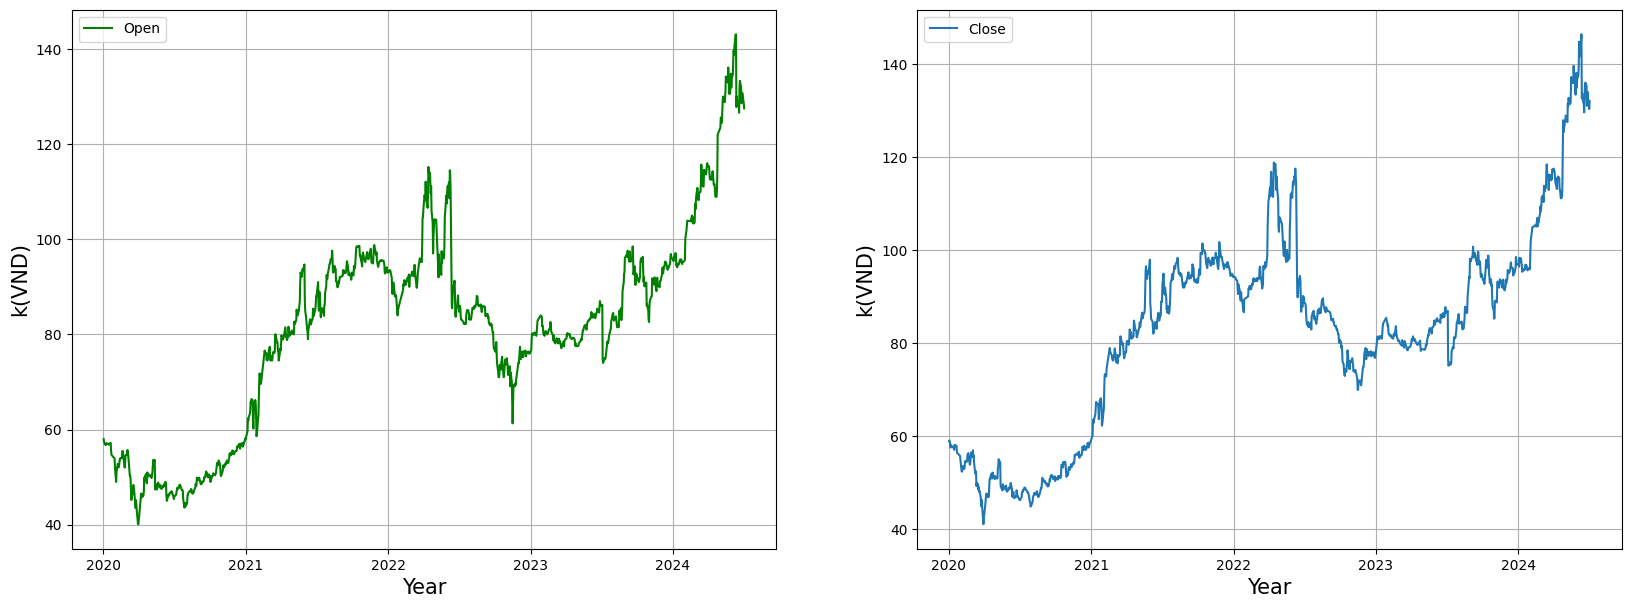

In [37]:
import matplotlib.pyplot as plt

# df_fpt = df[(df['symbols'] == 'FPT') & (df['date'] < '2024-01-02')]

# date = df_fpt[df_fpt['date'] < '2024-01-02' ]
date = df_fpt['date']
open = df_fpt.open / 1000
close = df_fpt.close / 1000

# plt.figure(figsize=(10,5))
fig, ax = plt.subplots(1,2,figsize=(20,7))

ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax[0].xaxis.set_major_locator(mdates.YearLocator(base=1))

ax[0].plot(date,open, label='Open',color='green')
ax[0].set_xlabel('Year',size=15)
ax[0].set_ylabel('k(VND)',size=15)

ax[0].legend()
ax[0].grid(True)

ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax[1].xaxis.set_major_locator(mdates.YearLocator(base=1))

ax[1].plot(date,close, label='Close')
ax[1].set_xlabel('Year',size=15)
ax[1].set_ylabel('k(VND)',size=15)

ax[1].legend()
ax[1].grid(True)

plt.show()
# close

**Dự đoán giá cổ phiếu FPT bằng LSTM**

In [ ]:
df_fpt = df[df['symbols'] == 'FPT']
df_fpt = df_fpt.set_index('date')
df_fpt[['close']]

,close
date,
2024-07-02,128000.0
2024-07-01,129000.0
2024-06-28,130500.0
2024-06-27,132800.0
2024-06-26,131800.0
...,...
2020-01-08,56800.0
2020-01-07,58100.0
2020-01-06,57000.0


24/10/18 00:23:14 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 7205293 ms exceeds timeout 120000 ms
24/10/18 00:23:14 WARN SparkContext: Killing executors is not supported by current scheduler.
24/10/18 00:23:15 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$